# 18 — Data Scaling and Learning Curves

## Research question

Is agent failure-family prediction currently limited primarily by dataset size,
or by the representation / label structure?

We evaluate fixed model architectures while varying only the amount of
training data available.

Failure families:

- workflow_error
- constraint_error
- tool_use_error
- grounding_state_error
- reasoning_value_error

Primary metrics:

- accuracy
- balanced accuracy
- macro-F1
- weighted-F1

Evaluation uses the same outer five-fold assignment used throughout the
previous relation-specific experiments.

No test-fold examples are used for training-set-size selection.

In [1]:
import numpy as np
import pandas as pd

from collections import Counter, defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    cross_val_predict,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

print("Notebook 17 initialized.")
CLASS_NAMES = [
    "workflow_error",
    "constraint_error",
    "tool_use_error",
    "grounding_state_error",
    "reasoning_value_error",
]

N_CLASSES = len(CLASS_NAMES)

# ============================================================
# 2. Load canonical trajectory exports
# ============================================================

train_events = pd.read_csv(
    "../data/processed/trajectory_events_train.csv"
)

test_events = pd.read_csv(
    "../data/processed/trajectory_events_test.csv"
)

targets = pd.read_csv(
    "../data/processed/trajectory_targets.csv"
)

train_targets = (
    targets[
        targets["split"] == "train"
    ]
    .reset_index(drop=True)
)

test_targets = (
    targets[
        targets["split"] == "test"
    ]
    .reset_index(drop=True)
)

print("Train events:", train_events.shape)
print("Test events:", test_events.shape)

print("Train targets:", train_targets.shape)
print("Test targets:", test_targets.shape)

assert len(train_targets) == 1489
assert len(test_targets) == 287

Notebook 17 initialized.
Train events: (3792, 40)
Test events: (799, 40)
Train targets: (1489, 14)
Test targets: (287, 14)


In [2]:
# ============================================================
# 3. Inspect dataset structure
# ============================================================

print("Train target columns:")
print(train_targets.columns.tolist())

print("\nTrain event columns:")
print(train_events.columns.tolist())

print("\nTrain failure-family distribution:")
display(
    train_targets["failure_family"]
    .value_counts()
    .rename_axis("failure_family")
    .reset_index(name="count")
)

print("\nTrain proportions:")
display(
    train_targets["failure_family"]
    .value_counts(normalize=True)
    .rename_axis("failure_family")
    .reset_index(name="proportion")
    .round(4)
)

print("\nTest failure-family distribution:")
display(
    test_targets["failure_family"]
    .value_counts()
    .rename_axis("failure_family")
    .reset_index(name="count")
)

# Candidate grouping columns.
group_candidates = [
    c for c in [
        "group_id",
        "canonical_group",
        "trajectory_index",
        "trajectory_id",
        "task_id",
    ]
    if c in train_targets.columns
]

print("\nCandidate grouping columns:")
for c in group_candidates:
    print(
        c,
        "| unique train:",
        train_targets[c].nunique(),
        "| unique test:",
        test_targets[c].nunique()
        if c in test_targets.columns
        else "N/A",
    )

Train target columns:
['dataset', 'group_id', 'canonical_group', 'split', 'trajectory_index', 'message_index', 'event_position', 'history_event_count', 'has_history', 'event_role', 'primary_tool', 'content', 'family_label', 'failure_family']

Train event columns:
['dataset', 'group_id', 'trajectory_index', 'message_index', 'event_role', 'current_role', 'content', 'primary_tool', 'char_length', 'word_count', 'has_content', 'has_error_signal', 'is_system', 'is_user', 'is_assistant', 'is_tool_call', 'is_tool_result', 'raw_step_label', 'raw_step_reason', 'context_text', 'previous_messages', 'previous_tool_calls', 'previous_tool_results', 'previous_user_messages', 'previous_assistant_messages', 'context_char_length', 'context_word_count', 'canonical_group', 'split', 'failure_family', 'family_label', 'is_taxonomy_target', 'event_position', 'trajectory_event_count', 'relative_event_position', 'previous_error_signals', 'previous_event_role', 'previous_event_tool', 'role_transition', 'tool_tran

,failure_family,count
0,workflow_error,660
1,constraint_error,317
2,grounding_state_error,244
3,tool_use_error,237
4,reasoning_value_error,31



Train proportions:


,failure_family,proportion
0,workflow_error,0.4433
1,constraint_error,0.2129
2,grounding_state_error,0.1639
3,tool_use_error,0.1592
4,reasoning_value_error,0.0208



Test failure-family distribution:


,failure_family,count
0,workflow_error,138
1,constraint_error,70
2,tool_use_error,38
3,grounding_state_error,30
4,reasoning_value_error,11



Candidate grouping columns:
group_id | unique train: 335 | unique test: 84
canonical_group | unique train: 335 | unique test: 84
trajectory_index | unique train: 205 | unique test: 76


In [3]:
# ============================================================
# 4. Verify grouping / leakage
# ============================================================

GROUP_COL = "canonical_group"

groups_train = (
    train_targets[GROUP_COL]
    .astype(str)
    .to_numpy()
)

groups_test = (
    test_targets[GROUP_COL]
    .astype(str)
    .to_numpy()
)

train_group_set = set(groups_train)
test_group_set = set(groups_test)

overlap = train_group_set & test_group_set

print("Grouping column:", GROUP_COL)
print("Train groups:", len(train_group_set))
print("Test groups:", len(test_group_set))
print("Overlap:", len(overlap))

if overlap:
    print("\nExample overlaps:")
    print(list(overlap)[:20])

Grouping column: canonical_group
Train groups: 335
Test groups: 84
Overlap: 0


In [8]:
from scripts.taxonomy_dataset import X_train_text_embeddings, X_test_text_embeddings, y_test, y_train

In [5]:
X_train = X_train_text_embeddings
X_test = X_test_text_embeddings

In [6]:
print(X_train.shape)
print(X_test.shape)

(1489, 384)
(287, 384)


In [9]:
# ============================================================
# 6. Group-level learning curve
# ============================================================

from sklearn.base import clone

TRAIN_FRACTIONS = [
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    1.00,
]

N_REPEATS = 10

base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
)

rng_master = np.random.RandomState(
    RANDOM_STATE
)

unique_groups = np.unique(
    groups_train
)

print("Unique train groups:", len(unique_groups))
print("Train examples:", len(y_train))
print("Fixed test examples:", len(y_test))

Unique train groups: 335
Train examples: 1489
Fixed test examples: 287


In [10]:
# ============================================================
# 7. Evaluation helper
# ============================================================

def evaluate_predictions(
    y_true,
    y_pred,
):
    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
            ),
    }

In [12]:
# ============================================================
# DEBUG: verify X / y / group alignment
# ============================================================

print("X_train:", X_train.shape)
print("y_train:", len(y_train))
print("groups_train:", len(groups_train))
print("train_targets:", len(train_targets))

print("\nFirst y values:")
print(y_train[:10])

print("\nFirst groups:")
print(groups_train[:10])

print("\nUnique y:")
print(np.unique(y_train, return_counts=True))

print("\nUnique groups:", len(np.unique(groups_train)))

assert len(X_train) == len(y_train)
assert len(y_train) == len(groups_train)

# Check group sizes
group_sizes = (
    pd.Series(groups_train)
    .value_counts()
)

print("\nGroup size summary:")
print(group_sizes.describe())

print("\nLargest groups:")
print(group_sizes.head(10))

X_train: (1489, 384)
y_train: 1489
groups_train: 1489
train_targets: 1489

First y values:
0    1
1    1
2    2
3    3
4    3
5    3
6    3
7    0
8    0
9    3
Name: family_label, dtype: int64

First groups:
['a_1' 'a_104' 'a_105' 'a_105' 'a_107' 'a_108' 'a_109' 'a_109' 'a_109'
 'a_115']

Unique y:
(array([0, 1, 2, 3, 4]), array([660, 317, 237, 244,  31]))

Unique groups: 335

Group size summary:
count    335.000000
mean       4.444776
std        7.970892
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       73.000000
Name: count, dtype: float64

Largest groups:
b_179    73
b_244    72
b_224    66
b_214    42
c_2      33
b_184    29
c_3      27
b_204    25
c_0      23
b_249    23
Name: count, dtype: int64


In [13]:
# ============================================================
# 6. Labels and groups
# ============================================================

CLASS_ID_TO_NAME = {
    0: "workflow_error",
    1: "constraint_error",
    2: "tool_use_error",
    3: "grounding_state_error",
    4: "reasoning_value_error",
}

CLASS_NAME_TO_ID = {
    v: k
    for k, v in CLASS_ID_TO_NAME.items()
}

CLASS_IDS = sorted(
    CLASS_ID_TO_NAME.keys()
)

CLASS_NAMES = [
    CLASS_ID_TO_NAME[i]
    for i in CLASS_IDS
]


# Numeric targets
y_train = (
    train_targets["family_label"]
    .astype(int)
    .to_numpy()
)

y_test = (
    test_targets["family_label"]
    .astype(int)
    .to_numpy()
)


# Groups
GROUP_COL = "canonical_group"

groups_train = (
    train_targets[GROUP_COL]
    .astype(str)
    .to_numpy()
)

groups_test = (
    test_targets[GROUP_COL]
    .astype(str)
    .to_numpy()
)


print(
    "Train label counts:"
)

print(
    pd.Series(y_train)
    .map(CLASS_ID_TO_NAME)
    .value_counts()
)

print(
    "\nTest label counts:"
)

print(
    pd.Series(y_test)
    .map(CLASS_ID_TO_NAME)
    .value_counts()
)

print(
    "\nTrain groups:",
    len(np.unique(groups_train))
)

print(
    "Test groups:",
    len(np.unique(groups_test))
)

Train label counts:
workflow_error           660
constraint_error         317
grounding_state_error    244
tool_use_error           237
reasoning_value_error     31
Name: count, dtype: int64

Test label counts:
workflow_error           138
constraint_error          70
tool_use_error            38
grounding_state_error     30
reasoning_value_error     11
Name: count, dtype: int64

Train groups: 335
Test groups: 84


In [15]:
# ============================================================
# Verify numeric label -> failure family mapping
# ============================================================

mapping_check = (
    train_targets[
        ["family_label", "failure_family"]
    ]
    .drop_duplicates()
    .sort_values("family_label")
)

display(mapping_check)

assert (
    mapping_check
    .set_index("family_label")[
        "failure_family"
    ]
    .to_dict()
    == CLASS_ID_TO_NAME
)

print("Class mapping verified.")

,family_label,failure_family
2,0.0,workflow_error
0,1.0,constraint_error
1,2.0,tool_use_error
9,3.0,grounding_state_error
48,4.0,reasoning_value_error


Class mapping verified.


In [21]:
# ============================================================
# 7. Verify train/test group separation
# ============================================================

train_groups_set = set(groups_train)
test_groups_set = set(groups_test)

overlap = train_groups_set & test_groups_set

print("Train groups:", len(train_groups_set))
print("Test groups:", len(test_groups_set))
print("Group overlap:", len(overlap))

if overlap:
    print("Overlapping groups:")
    print(sorted(overlap)[:30])
else:
    print("OK: no canonical-group leakage.")

Train groups: 335
Test groups: 84
Group overlap: 0
OK: no canonical-group leakage.


In [22]:
# ============================================================
# 8. Group-level subset sampler
# ============================================================

TRAIN_FRACTIONS = [
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    1.00,
]

N_REPEATS = 20

unique_groups = np.unique(groups_train)

print("Available groups:", len(unique_groups))


def sample_group_subset(
    fraction,
    repeat,
):
    rng = np.random.RandomState(
        RANDOM_STATE
        + int(fraction * 10000)
        + repeat
    )

    n_groups = max(
        1,
        round(
            len(unique_groups) * fraction
        )
    )

    if fraction == 1.0:
        selected_groups = unique_groups.copy()

    else:
        selected_groups = rng.choice(
            unique_groups,
            size=n_groups,
            replace=False,
        )

    mask = np.isin(
        groups_train,
        selected_groups,
    )

    idx = np.flatnonzero(mask)

    return idx, selected_groups

Available groups: 335


In [23]:
# ============================================================
# 9. Main data-scaling experiment
# ============================================================

from sklearn.base import clone

base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
)

rows = []

for fraction in TRAIN_FRACTIONS:

    repeats = (
        1
        if fraction == 1.0
        else N_REPEATS
    )

    for repeat in range(repeats):

        idx, selected_groups = (
            sample_group_subset(
                fraction,
                repeat,
            )
        )

        y_sub = y_train[idx]

        present_classes = np.unique(y_sub)

        if len(present_classes) < 2:
            print(
                "Skipping:",
                fraction,
                repeat,
                "only",
                present_classes,
            )
            continue

        model = clone(base_model)

        model.fit(
            X_train[idx],
            y_sub,
        )

        pred = model.predict(X_test)

        row = {
            "fraction": fraction,
            "repeat": repeat,
            "n_groups": len(selected_groups),
            "n_examples": len(idx),

            "accuracy":
                accuracy_score(
                    y_test,
                    pred,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_test,
                    pred,
                ),

            "macro_f1":
                f1_score(
                    y_test,
                    pred,
                    average="macro",
                ),

            "weighted_f1":
                f1_score(
                    y_test,
                    pred,
                    average="weighted",
                ),
        }

        # Record class exposure in training subset
        counts = Counter(y_sub)

        for class_id in CLASS_IDS:

            family = CLASS_ID_TO_NAME[
                class_id
            ]

            row[
                f"train_n_{family}"
            ] = counts.get(
                class_id,
                0,
            )

        rows.append(row)


learning_curve_df = pd.DataFrame(rows)

print(
    "Completed runs:",
    len(learning_curve_df)
)

display(
    learning_curve_df.head()
)

Completed runs: 101


,fraction,repeat,n_groups,n_examples,accuracy,balanced_accuracy,macro_f1,weighted_f1,train_n_workflow_error,train_n_constraint_error,train_n_tool_use_error,train_n_grounding_state_error,train_n_reasoning_value_error
0,0.1,0,34,165,0.310105,0.214887,0.188004,0.286613,103,20,15,22,5
1,0.1,1,34,120,0.233449,0.215384,0.176389,0.234444,33,43,15,28,1
2,0.1,2,34,125,0.327526,0.236217,0.219677,0.323162,38,37,19,28,3
3,0.1,3,34,122,0.317073,0.261869,0.249074,0.330657,39,33,25,18,7
4,0.1,4,34,193,0.306620,0.160680,0.153942,0.282912,122,43,14,11,3


In [24]:
# ============================================================
# 10. Learning-curve summary
# ============================================================

learning_curve_summary = (
    learning_curve_df
    .groupby("fraction")
    .agg(
        runs=("repeat", "count"),

        examples_mean=("n_examples", "mean"),
        examples_std=("n_examples", "std"),

        groups_mean=("n_groups", "mean"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),

        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),

        weighted_f1_mean=(
            "weighted_f1",
            "mean",
        ),
        weighted_f1_std=(
            "weighted_f1",
            "std",
        ),
    )
    .reset_index()
)

display(
    learning_curve_summary.round(4)
)

,fraction,runs,examples_mean,examples_std,groups_mean,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,0.1,20,137.15,43.4127,34.0,0.2847,0.0527,0.2044,0.0282,0.1832,0.0291,0.2773,0.0462
1,0.2,20,301.30,68.8049,67.0,0.3064,0.0339,0.2282,0.0294,0.2064,0.0304,0.3071,0.0382
2,0.4,20,561.60,57.6015,134.0,0.3030,0.0346,0.2311,0.0208,0.2112,0.0200,0.3053,0.0329
3,0.6,20,912.45,49.4363,201.0,0.2909,0.0271,0.2176,0.0185,0.1946,0.0171,0.2857,0.0238
4,0.8,20,1196.75,42.8312,268.0,0.2711,0.0195,0.2068,0.0175,0.1841,0.0150,0.2700,0.0172
5,1.0,1,1489.00,NaN,335.0,0.2648,NaN,0.2051,NaN,0.1816,NaN,0.2637,NaN


In [25]:
# ============================================================
# 11. How much class evidence is available as data scales?
# ============================================================

class_count_cols = [
    f"train_n_{CLASS_ID_TO_NAME[i]}"
    for i in CLASS_IDS
]

class_exposure = (
    learning_curve_df
    .groupby("fraction")[
        class_count_cols
    ]
    .agg(["mean", "std", "min", "max"])
)

display(
    class_exposure.round(2)
)

train_n_workflow_error                  train_n_constraint_error                  train_n_tool_use_error                  train_n_grounding_state_error                   \
                           mean    std  min  max                     mean    std  min  max                   mean    std  min  max                          mean    std  min  max   
fraction                                                                                                                                                                            
0.1                       57.20  38.92   23  173                    34.10   9.27   17   48                  19.85   5.82    6   31                         23.10  10.11    7   44   
0.2                      132.50  60.45   53  251                    69.10  14.24   48  111                  43.60  12.43   25   75                         50.15  17.01   26   84   
0.4                      241.05  49.23  150  327                   120.65  15.02   99  153                  90.15  13.21   72  124                         98.00  15.20   78  131   
0.6                      413.20  40.09  338  476                   192.55  15.89  160  224                 141.80   9.76  115  161                        146.25  16.00  113  172   
0.8                      536.55  34.01  487  597                   249.40   8.89  236  265                 192.20   7.75  178  204                        195.45  16.14  161  219   
1.0                      660.00    NaN  660  660                   317.00    NaN  317  317                 237.00    NaN  237  237                        244.00    NaN  244  244   

         train_n_reasoning_value_error                
                                  mean   std min max  
fraction                                              
0.1                               2.90  2.07   0   7  
0.2                               5.95  2.89   1  11  
0.4                              11.75  3.42   6  18  
0.6                              18.65  3.23  12  24  
0.8                              23.15  4.40  14  29  
1.0                              31.00   NaN  31  31

In [26]:
# ============================================================
# 12. Per-family scaling
# ============================================================

family_rows = []

for fraction in TRAIN_FRACTIONS:

    repeats = (
        1
        if fraction == 1.0
        else N_REPEATS
    )

    for repeat in range(repeats):

        idx, selected_groups = (
            sample_group_subset(
                fraction,
                repeat,
            )
        )

        y_sub = y_train[idx]

        if len(np.unique(y_sub)) < 2:
            continue

        model = clone(base_model)

        model.fit(
            X_train[idx],
            y_sub,
        )

        pred = model.predict(X_test)

        report = classification_report(
            y_test,
            pred,
            labels=CLASS_IDS,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )

        for family in CLASS_NAMES:

            family_rows.append({
                "fraction": fraction,
                "repeat": repeat,
                "family": family,
                "precision":
                    report[family]["precision"],
                "recall":
                    report[family]["recall"],
                "f1":
                    report[family]["f1-score"],
            })


family_curve_df = pd.DataFrame(
    family_rows
)

family_curve_summary = (
    family_curve_df
    .groupby(
        ["fraction", "family"]
    )
    .agg(
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .reset_index()
)

display(
    family_curve_summary.round(4)
)

,fraction,family,precision_mean,recall_mean,recall_std,f1_mean,f1_std
0,0.1,constraint_error,0.2136,0.1986,0.1374,0.1936,0.0988
1,0.1,grounding_state_error,0.1388,0.2550,0.1361,0.1664,0.0684
2,0.1,reasoning_value_error,0.0148,0.0136,0.0333,0.0138,0.0342
3,0.1,tool_use_error,0.1440,0.1658,0.1120,0.1395,0.0700
4,0.1,workflow_error,0.4508,0.3891,0.1485,0.4028,0.0998
5,0.2,constraint_error,0.2711,0.2171,0.1349,0.2324,0.1224
6,0.2,grounding_state_error,0.1553,0.3167,0.1137,0.1999,0.0509
7,0.2,reasoning_value_error,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.2,tool_use_error,0.1595,0.2053,0.1128,0.1691,0.0536
9,0.2,workflow_error,0.4788,0.4018,0.0748,0.4307,0.0485


In [27]:
# ============================================================
# 13. Sanity baselines on fixed test set
# ============================================================

majority_class = Counter(y_train).most_common(1)[0][0]

majority_pred = np.full(
    len(y_test),
    majority_class,
    dtype=int,
)

print(
    "Majority class:",
    CLASS_ID_TO_NAME[majority_class]
)

print(
    "Majority accuracy:",
    accuracy_score(
        y_test,
        majority_pred,
    )
)

print(
    "Majority balanced accuracy:",
    balanced_accuracy_score(
        y_test,
        majority_pred,
    )
)

print(
    "Majority macro F1:",
    f1_score(
        y_test,
        majority_pred,
        average="macro",
    )
)

Majority class: workflow_error
Majority accuracy: 0.4808362369337979
Majority balanced accuracy: 0.2
Majority macro F1: 0.12988235294117648


In [28]:
# ============================================================
# 14. Does X_train reproduce the old semantic signal?
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

train_oof_pred = cross_val_predict(
    clone(base_model),
    X_train,
    y_train,
    cv=skf,
    method="predict",
)

train_oof_metrics = {
    "accuracy":
        accuracy_score(
            y_train,
            train_oof_pred,
        ),

    "balanced_accuracy":
        balanced_accuracy_score(
            y_train,
            train_oof_pred,
        ),

    "macro_f1":
        f1_score(
            y_train,
            train_oof_pred,
            average="macro",
        ),

    "weighted_f1":
        f1_score(
            y_train,
            train_oof_pred,
            average="weighted",
        ),
}

print(train_oof_metrics)

{'accuracy': 0.4049697783747482, 'balanced_accuracy': 0.2944364625683592, 'macro_f1': 0.29677095899700473, 'weighted_f1': 0.40006338255405055}


In [29]:
# ============================================================
# 15. Train-fit vs OOF vs external test
# ============================================================

full_model = clone(base_model)

full_model.fit(
    X_train,
    y_train,
)

train_fit_pred = full_model.predict(
    X_train
)

test_pred = full_model.predict(
    X_test
)


comparison = pd.DataFrame([
    {
        "split": "train_fit",
        "accuracy":
            accuracy_score(
                y_train,
                train_fit_pred,
            ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_train,
                train_fit_pred,
            ),
        "macro_f1":
            f1_score(
                y_train,
                train_fit_pred,
                average="macro",
            ),
    },

    {
        "split": "train_OOF",
        "accuracy":
            accuracy_score(
                y_train,
                train_oof_pred,
            ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_train,
                train_oof_pred,
            ),
        "macro_f1":
            f1_score(
                y_train,
                train_oof_pred,
                average="macro",
            ),
    },

    {
        "split": "fixed_test",
        "accuracy":
            accuracy_score(
                y_test,
                test_pred,
            ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                test_pred,
            ),
        "macro_f1":
            f1_score(
                y_test,
                test_pred,
                average="macro",
            ),
    },
])

display(
    comparison.round(4)
)

,split,accuracy,balanced_accuracy,macro_f1
0,train_fit,0.7542,0.7580,0.7675
1,train_OOF,0.4050,0.2944,0.2968
2,fixed_test,0.2648,0.2051,0.1816


In [30]:
# ============================================================
# 16. Test prediction distribution
# ============================================================

print("TRUE TEST DISTRIBUTION")
print(
    pd.Series(y_test)
    .map(CLASS_ID_TO_NAME)
    .value_counts()
)

print("\nPREDICTED TEST DISTRIBUTION")
print(
    pd.Series(test_pred)
    .map(CLASS_ID_TO_NAME)
    .value_counts()
)


cm = confusion_matrix(
    y_test,
    test_pred,
    labels=CLASS_IDS,
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)

display(cm_df)

TRUE TEST DISTRIBUTION
workflow_error           138
constraint_error          70
tool_use_error            38
grounding_state_error     30
reasoning_value_error     11
Name: count, dtype: int64

PREDICTED TEST DISTRIBUTION
workflow_error           119
tool_use_error            70
grounding_state_error     54
constraint_error          43
reasoning_value_error      1
Name: count, dtype: int64


,workflow_error,constraint_error,tool_use_error,grounding_state_error,reasoning_value_error
workflow_error,51,23,37,26,1
constraint_error,42,6,15,7,0
tool_use_error,14,6,9,9,0
grounding_state_error,8,7,5,10,0
reasoning_value_error,4,1,4,2,0


In [31]:
# ============================================================
# 17. Representation distribution sanity check
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTRAIN")
print("mean:", X_train.mean())
print("std :", X_train.std())
print("min :", X_train.min())
print("max :", X_train.max())

print("\nTEST")
print("mean:", X_test.mean())
print("std :", X_test.std())
print("min :", X_test.min())
print("max :", X_test.max())


train_norm = np.linalg.norm(
    X_train,
    axis=1,
)

test_norm = np.linalg.norm(
    X_test,
    axis=1,
)

print("\nEmbedding norms")

print(
    "Train:",
    np.mean(train_norm),
    np.std(train_norm),
)

print(
    "Test:",
    np.mean(test_norm),
    np.std(test_norm),
)

X_train shape: (1489, 384)
X_test shape: (287, 384)

TRAIN
mean: -0.00040869685
std : 0.051029395
min : -0.23809114
max : 0.23004244

TEST
mean: -0.00036119643
std : 0.05102976
min : -0.24236742
max : 0.23282447

Embedding norms
Train: 1.0 4.2583324e-08
Test: 1.0 4.1331266e-08


In [32]:
# ============================================================
# 18. Train/test domain composition
# ============================================================

train_domain = (
    pd.Series(groups_train)
    .str.split("_")
    .str[0]
)

test_domain = (
    pd.Series(groups_test)
    .str.split("_")
    .str[0]
)


domain_counts = pd.concat(
    [
        train_domain
        .value_counts()
        .rename("train_count"),

        test_domain
        .value_counts()
        .rename("test_count"),
    ],
    axis=1,
).fillna(0)

domain_counts["train_prop"] = (
    domain_counts["train_count"]
    / domain_counts["train_count"].sum()
)

domain_counts["test_prop"] = (
    domain_counts["test_count"]
    / domain_counts["test_count"].sum()
)

display(
    domain_counts.round(4)
)

,train_count,test_count,train_prop,test_prop
b,940,133,0.6313,0.4634
c,441,98,0.2962,0.3415
a,108,56,0.0725,0.1951


In [33]:
# ============================================================
# 19. Failure-family distribution by domain
# ============================================================

train_domain_df = pd.DataFrame({
    "domain": train_domain.to_numpy(),
    "family_id": y_train,
})

train_domain_df["family"] = (
    train_domain_df["family_id"]
    .map(CLASS_ID_TO_NAME)
)


test_domain_df = pd.DataFrame({
    "domain": test_domain.to_numpy(),
    "family_id": y_test,
})

test_domain_df["family"] = (
    test_domain_df["family_id"]
    .map(CLASS_ID_TO_NAME)
)


print("=" * 70)
print("TRAIN: DOMAIN × FAILURE FAMILY")

display(
    pd.crosstab(
        train_domain_df["domain"],
        train_domain_df["family"],
        normalize="index",
    ).round(3)
)


print("=" * 70)
print("TEST: DOMAIN × FAILURE FAMILY")

display(
    pd.crosstab(
        test_domain_df["domain"],
        test_domain_df["family"],
        normalize="index",
    ).round(3)
)

TRAIN: DOMAIN × FAILURE FAMILY


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,0.148,0.324,0.028,0.167,0.333
b,0.251,0.090,0.003,0.140,0.515
c,0.147,0.281,0.057,0.197,0.317


TEST: DOMAIN × FAILURE FAMILY


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,0.036,0.179,0.071,0.107,0.607
b,0.398,0.060,0.008,0.120,0.414
c,0.153,0.122,0.061,0.163,0.500


In [34]:
print("=" * 70)
print("TRAIN COUNTS")

display(
    pd.crosstab(
        train_domain_df["domain"],
        train_domain_df["family"],
    )
)


print("=" * 70)
print("TEST COUNTS")

display(
    pd.crosstab(
        test_domain_df["domain"],
        test_domain_df["family"],
    )
)

TRAIN COUNTS


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,16,35,3,18,36
b,236,85,3,132,484
c,65,124,25,87,140


TEST COUNTS


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,2,10,4,6,34
b,53,8,1,16,55
c,15,12,6,16,49


In [36]:
# ============================================================
# Find probability matrices and their metrics
# ============================================================

candidate_names = [
    "full_prob",
    "remove_t1_prob",
    "P_semantic",
    "P",
    "meta_oof_prob",
]

rows = []

for name in candidate_names:

    if name not in globals():
        continue

    arr = np.asarray(
        globals()[name]
    )

    if (
        arr.ndim != 2
        or arr.shape != (1489, 5)
    ):
        continue

    pred = arr.argmax(axis=1)

    rows.append({
        "name": name,
        "shape": arr.shape,
        "accuracy":
            accuracy_score(
                np.asarray(y),
                pred,
            ),
        "balanced_accuracy":
            balanced_accuracy_score(
                np.asarray(y),
                pred,
            ),
        "macro_f1":
            f1_score(
                np.asarray(y),
                pred,
                average="macro",
            ),
        "weighted_f1":
            f1_score(
                np.asarray(y),
                pred,
                average="weighted",
            ),
    })


display(
    pd.DataFrame(rows)
    .sort_values(
        "accuracy",
        ascending=False,
    )
    .round(4)
)

KeyError: 'accuracy'

In [37]:
# ============================================================
# 20. Search current notebook for candidate probability arrays
# ============================================================

prob_candidates = []

for name, obj in list(globals().items()):

    try:
        arr = np.asarray(obj)
    except Exception:
        continue

    if (
        arr.ndim == 2
        and arr.shape[0] == len(y_train)
        and arr.shape[1] == N_CLASSES
    ):
        prob_candidates.append({
            "name": name,
            "shape": arr.shape,
            "dtype": str(arr.dtype),
            "min": float(np.nanmin(arr)),
            "max": float(np.nanmax(arr)),
        })


prob_candidates_df = pd.DataFrame(
    prob_candidates
)

if prob_candidates_df.empty:
    print(
        "No (1489, 5) arrays exist in this fresh kernel."
    )
else:
    display(prob_candidates_df)

No (1489, 5) arrays exist in this fresh kernel.


In [38]:
# ============================================================
# 21. Group-aware OOF embedding baseline
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

group_oof_pred = np.full(
    len(y_train),
    -1,
    dtype=int,
)

fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    sgkf.split(
        X_train,
        y_train,
        groups_train,
    ),
    start=1,
):

    model = clone(base_model)

    model.fit(
        X_train[tr_idx],
        y_train[tr_idx],
    )

    pred = model.predict(
        X_train[va_idx]
    )

    group_oof_pred[va_idx] = pred

    fold_rows.append({
        "fold": fold,
        "train_n": len(tr_idx),
        "valid_n": len(va_idx),

        "train_groups":
            len(np.unique(groups_train[tr_idx])),

        "valid_groups":
            len(np.unique(groups_train[va_idx])),

        "accuracy":
            accuracy_score(
                y_train[va_idx],
                pred,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_train[va_idx],
                pred,
            ),

        "macro_f1":
            f1_score(
                y_train[va_idx],
                pred,
                average="macro",
            ),

        "weighted_f1":
            f1_score(
                y_train[va_idx],
                pred,
                average="weighted",
            ),
    })


assert (group_oof_pred >= 0).all()

group_oof_fold_df = pd.DataFrame(
    fold_rows
)

display(
    group_oof_fold_df.round(4)
)


group_oof_metrics = pd.DataFrame([
    {
        "evaluation":
            "ordinary_stratified_OOF",

        "accuracy":
            accuracy_score(
                y_train,
                train_oof_pred,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_train,
                train_oof_pred,
            ),

        "macro_f1":
            f1_score(
                y_train,
                train_oof_pred,
                average="macro",
            ),

        "weighted_f1":
            f1_score(
                y_train,
                train_oof_pred,
                average="weighted",
            ),
    },

    {
        "evaluation":
            "group_aware_OOF",

        "accuracy":
            accuracy_score(
                y_train,
                group_oof_pred,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_train,
                group_oof_pred,
            ),

        "macro_f1":
            f1_score(
                y_train,
                group_oof_pred,
                average="macro",
            ),

        "weighted_f1":
            f1_score(
                y_train,
                group_oof_pred,
                average="weighted",
            ),
    },
])

display(
    group_oof_metrics.round(4)
)

,fold,train_n,valid_n,train_groups,valid_groups,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,1190,299,267,68,0.3445,0.2410,0.2458,0.3387
1,2,1191,298,267,68,0.3356,0.2305,0.2307,0.3334
2,3,1191,298,268,67,0.3423,0.2316,0.2320,0.3384
3,4,1192,297,271,64,0.3131,0.2199,0.2218,0.3124
4,5,1192,297,267,68,0.3333,0.2499,0.2455,0.3361


,evaluation,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,ordinary_stratified_OOF,0.4050,0.2944,0.2968,0.4001
1,group_aware_OOF,0.3338,0.2345,0.2344,0.3312


In [39]:
# ============================================================
# 22. Group-aware learning curve
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone

FRACTIONS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
N_REPEATS = 10

curve_rows = []

unique_groups = np.unique(groups_train)

for repeat in range(N_REPEATS):

    # --------------------------------------------------------
    # Fixed held-out groups for this repeat
    # --------------------------------------------------------
    outer = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE + repeat,
    )

    pool_idx, valid_idx = next(
        outer.split(
            X_train,
            y_train,
            groups_train,
        )
    )

    pool_groups = np.unique(
        groups_train[pool_idx]
    )

    rng = np.random.default_rng(
        RANDOM_STATE + 1000 + repeat
    )

    shuffled_groups = rng.permutation(
        pool_groups
    )

    for fraction in FRACTIONS:

        n_groups = max(
            1,
            int(
                round(
                    fraction *
                    len(shuffled_groups)
                )
            )
        )

        selected_groups = shuffled_groups[
            :n_groups
        ]

        train_mask = np.isin(
            groups_train[pool_idx],
            selected_groups,
        )

        sub_train_idx = pool_idx[
            train_mask
        ]

        # Need all classes for multiclass evaluation
        present_classes = np.unique(
            y_train[sub_train_idx]
        )

        if len(present_classes) < N_CLASSES:
            continue

        model = clone(base_model)

        model.fit(
            X_train[sub_train_idx],
            y_train[sub_train_idx],
        )

        pred = model.predict(
            X_train[valid_idx]
        )

        row = {
            "repeat": repeat,
            "fraction": fraction,

            "n_groups":
                len(selected_groups),

            "n_examples":
                len(sub_train_idx),

            "valid_groups":
                len(
                    np.unique(
                        groups_train[valid_idx]
                    )
                ),

            "accuracy":
                accuracy_score(
                    y_train[valid_idx],
                    pred,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_train[valid_idx],
                    pred,
                ),

            "macro_f1":
                f1_score(
                    y_train[valid_idx],
                    pred,
                    average="macro",
                ),

            "weighted_f1":
                f1_score(
                    y_train[valid_idx],
                    pred,
                    average="weighted",
                ),
        }

        # class support
        counts = Counter(
            y_train[sub_train_idx]
        )

        for class_id, class_name in enumerate(
            CLASS_NAMES
        ):
            row[
                f"train_n_{class_name}"
            ] = counts.get(
                class_id,
                0,
            )

        curve_rows.append(row)


group_learning_curve = pd.DataFrame(
    curve_rows
)

display(
    group_learning_curve.head(20)
)

,repeat,fraction,n_groups,n_examples,valid_groups,accuracy,balanced_accuracy,macro_f1,weighted_f1,train_n_workflow_error,train_n_constraint_error,train_n_tool_use_error,train_n_grounding_state_error,train_n_reasoning_value_error
0,0,0.1,27,146,67,0.394737,0.202026,0.181031,0.335030,90,27,20,7,2
1,0,0.2,54,253,67,0.398026,0.331307,0.274641,0.372372,115,48,33,47,10
2,0,0.4,107,532,67,0.430921,0.280621,0.282116,0.424025,236,97,70,115,14
3,0,0.6,161,772,67,0.335526,0.239641,0.235656,0.337199,339,158,114,142,19
4,0,0.8,214,1000,67,0.338816,0.229869,0.228590,0.336356,450,193,151,179,27
5,0,1.0,268,1185,67,0.309211,0.198595,0.198983,0.309708,524,227,201,204,29
6,1,0.1,27,178,67,0.312684,0.203168,0.175866,0.335784,89,41,19,27,2
7,1,0.2,54,333,67,0.292035,0.205856,0.175103,0.320682,151,85,33,56,8
8,1,0.4,107,513,67,0.292035,0.209742,0.188780,0.330793,202,120,77,106,8
9,1,0.6,161,667,67,0.321534,0.216502,0.202798,0.355845,262,148,109,132,16


In [40]:
# ============================================================
# 23. Summarize group-aware learning curve
# ============================================================

group_curve_summary = (
    group_learning_curve
    .groupby("fraction")
    .agg(
        runs=("accuracy", "size"),

        examples_mean=(
            "n_examples",
            "mean",
        ),
        examples_std=(
            "n_examples",
            "std",
        ),

        groups_mean=(
            "n_groups",
            "mean",
        ),

        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        accuracy_std=(
            "accuracy",
            "std",
        ),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),

        macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        macro_f1_std=(
            "macro_f1",
            "std",
        ),

        weighted_f1_mean=(
            "weighted_f1",
            "mean",
        ),
        weighted_f1_std=(
            "weighted_f1",
            "std",
        ),
    )
    .reset_index()
)

display(
    group_curve_summary.round(4)
)

,fraction,runs,examples_mean,examples_std,groups_mean,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,0.1,10,123.2,41.4402,27.0,0.3153,0.0691,0.2373,0.0647,0.2097,0.0525,0.3068,0.0630
1,0.2,10,250.4,48.9244,54.0,0.3136,0.0603,0.2281,0.0475,0.2072,0.0401,0.3106,0.0546
2,0.4,10,495.1,45.1182,107.0,0.3328,0.0557,0.2365,0.0219,0.2281,0.0300,0.3369,0.0509
3,0.6,10,726.6,44.9325,161.0,0.3199,0.0280,0.2246,0.0301,0.2175,0.0295,0.3232,0.0296
4,0.8,10,962.7,51.7753,214.0,0.3123,0.0430,0.2220,0.0229,0.2137,0.0269,0.3142,0.0421
5,1.0,10,1189.8,34.4635,268.0,0.3138,0.0309,0.2228,0.0236,0.2158,0.0271,0.3194,0.0299


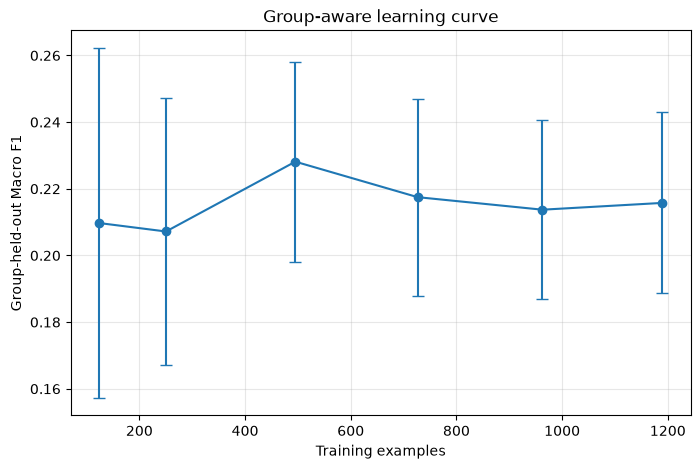

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(
    group_curve_summary["examples_mean"],
    group_curve_summary["macro_f1_mean"],
    yerr=group_curve_summary["macro_f1_std"],
    marker="o",
    capsize=4,
)

plt.xlabel("Training examples")
plt.ylabel("Group-held-out Macro F1")
plt.title("Group-aware learning curve")

plt.grid(alpha=0.3)
plt.show()

In [42]:
# ============================================================
# 24. Diversity-controlled learning curves
# ============================================================

from collections import Counter

# One row per training example
sampling_df = pd.DataFrame({
    "group": groups_train,
    "family_label": np.asarray(y_train),
})

sampling_df["family"] = sampling_df["family_label"].map(
    dict(enumerate(CLASS_NAMES))
)

# Infer domain from canonical group IDs: a_..., b_..., c_...
sampling_df["domain"] = (
    sampling_df["group"]
    .astype(str)
    .str.split("_")
    .str[0]
)

display(sampling_df.head())

print("Domains:")
print(sampling_df["domain"].value_counts())

print("\nFamilies:")
print(sampling_df["family"].value_counts())

print("\nDomain × family:")
display(
    pd.crosstab(
        sampling_df["domain"],
        sampling_df["family"]
    )
)

,group,family_label,family,domain
0,a_1,1,constraint_error,a
1,a_104,2,tool_use_error,a
2,a_105,0,workflow_error,a
3,a_105,1,constraint_error,a
4,a_107,1,constraint_error,a


Domains:
domain
b    940
c    441
a    108
Name: count, dtype: int64

Families:
family
workflow_error           660
constraint_error         317
grounding_state_error    244
tool_use_error           237
reasoning_value_error     31
Name: count, dtype: int64

Domain × family:


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,16,35,3,18,36
b,236,85,3,132,484
c,65,124,25,87,140


In [43]:
# ============================================================
# 25. Group-level composition
# ============================================================

group_rows = []

for group_id, part in sampling_df.groupby("group"):

    family_counts = part["family"].value_counts()
    domain_counts = part["domain"].value_counts()

    row = {
        "group": group_id,
        "n_examples": len(part),
        "domain": domain_counts.index[0],
        "dominant_family": family_counts.index[0],
        "n_families": part["family"].nunique(),
    }

    for family in CLASS_NAMES:
        row[f"n_{family}"] = int(
            family_counts.get(family, 0)
        )

    group_rows.append(row)

group_meta = pd.DataFrame(group_rows)

print("Groups:", len(group_meta))
display(group_meta.head())

print("\nDomain distribution by group:")
print(group_meta["domain"].value_counts())

print("\nDominant family distribution:")
print(group_meta["dominant_family"].value_counts())

print("\nGroup size:")
display(group_meta["n_examples"].describe())

Groups: 335


,group,n_examples,domain,dominant_family,n_families,n_workflow_error,n_constraint_error,n_tool_use_error,n_grounding_state_error,n_reasoning_value_error
0,a_1,1,a,constraint_error,1,0,1,0,0,0
1,a_104,1,a,tool_use_error,1,0,0,1,0,0
2,a_105,2,a,workflow_error,2,1,1,0,0,0
3,a_107,1,a,constraint_error,1,0,1,0,0,0
4,a_108,1,a,constraint_error,1,0,1,0,0,0



Domain distribution by group:
domain
c    145
b    123
a     67
Name: count, dtype: int64

Dominant family distribution:
dominant_family
workflow_error           102
constraint_error          84
tool_use_error            73
grounding_state_error     65
reasoning_value_error     11
Name: count, dtype: int64

Group size:


count    335.000000
mean       4.444776
std        7.970892
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       73.000000
Name: n_examples, dtype: float64

In [44]:
# ============================================================
# 26. Group acquisition strategies
# ============================================================

def sample_random_groups(meta, n_groups, rng):
    n_groups = min(n_groups, len(meta))

    return rng.choice(
        meta["group"].values,
        size=n_groups,
        replace=False,
    )


def sample_balanced_groups(
    meta,
    n_groups,
    strata_cols,
    rng,
):
    """
    Approximately equal allocation across strata while
    sampling whole groups without replacement.
    """

    meta = meta.copy()

    strata = list(
        meta.groupby(
            strata_cols,
            dropna=False,
        ).groups.keys()
    )

    # Normalize single-column groupby keys
    if len(strata_cols) == 1:
        strata = [(s,) for s in strata]

    selected = []
    used = set()

    # Randomize order so leftover allocations don't always
    # favor the same cells.
    strata = list(strata)
    rng.shuffle(strata)

    # Round-robin acquisition gives approximately equal
    # representation across available cells.
    while len(selected) < n_groups:

        added_this_round = False

        for stratum in strata:

            if len(selected) >= n_groups:
                break

            mask = np.ones(len(meta), dtype=bool)

            for col, value in zip(strata_cols, stratum):
                mask &= meta[col].values == value

            candidates = meta.loc[
                mask & ~meta["group"].isin(used),
                "group"
            ].values

            if len(candidates) == 0:
                continue

            chosen = rng.choice(candidates)

            selected.append(chosen)
            used.add(chosen)

            added_this_round = True

        if not added_this_round:
            break

    # Fill remaining budget randomly if some strata exhaust.
    if len(selected) < n_groups:

        remaining = meta.loc[
            ~meta["group"].isin(used),
            "group"
        ].values

        need = min(
            n_groups - len(selected),
            len(remaining),
        )

        if need > 0:
            extra = rng.choice(
                remaining,
                size=need,
                replace=False,
            )

            selected.extend(extra.tolist())

    return np.asarray(selected)


def acquire_groups(
    meta,
    n_groups,
    strategy,
    rng,
):

    if strategy == "random":
        return sample_random_groups(
            meta,
            n_groups,
            rng,
        )

    elif strategy == "domain_balanced":
        return sample_balanced_groups(
            meta,
            n_groups,
            ["domain"],
            rng,
        )

    elif strategy == "domain_family_balanced":
        return sample_balanced_groups(
            meta,
            n_groups,
            ["domain", "dominant_family"],
            rng,
        )

    else:
        raise ValueError(
            f"Unknown strategy: {strategy}"
        )

In [45]:
# ============================================================
# 27. Sanity check acquisition strategies
# ============================================================

rng = np.random.default_rng(RANDOM_STATE)

for strategy in [
    "random",
    "domain_balanced",
    "domain_family_balanced",
]:

    chosen = acquire_groups(
        group_meta,
        n_groups=100,
        strategy=strategy,
        rng=rng,
    )

    tmp = sampling_df[
        sampling_df["group"].isin(chosen)
    ]

    print("\n" + "=" * 70)
    print(strategy)
    print("=" * 70)

    print("Groups:", len(chosen))
    print("Examples:", len(tmp))

    print("\nDomain proportions:")
    print(
        tmp["domain"]
        .value_counts(normalize=True)
        .round(3)
    )

    print("\nFamily proportions:")
    print(
        tmp["family"]
        .value_counts(normalize=True)
        .round(3)
    )

    print("\nDomain × family counts:")
    display(
        pd.crosstab(
            tmp["domain"],
            tmp["family"]
        )
    )


random
Groups: 100
Examples: 574

Domain proportions:
domain
b    0.695
c    0.263
a    0.042
Name: proportion, dtype: float64

Family proportions:
family
workflow_error           0.514
constraint_error         0.171
grounding_state_error    0.166
tool_use_error           0.129
reasoning_value_error    0.021
Name: proportion, dtype: float64

Domain × family counts:


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,2,9,2,5,6
b,82,30,0,45,242
c,14,56,10,24,47



domain_balanced
Groups: 100
Examples: 452

Domain proportions:
domain
b    0.626
c    0.228
a    0.146
Name: proportion, dtype: float64

Family proportions:
family
workflow_error           0.460
constraint_error         0.184
tool_use_error           0.166
grounding_state_error    0.164
reasoning_value_error    0.027
Name: proportion, dtype: float64

Domain × family counts:


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,10,20,2,10,24
b,64,29,1,46,143
c,9,25,9,19,41



domain_family_balanced
Groups: 100
Examples: 292

Domain proportions:
domain
b    0.449
c    0.349
a    0.202
Name: proportion, dtype: float64

Family proportions:
family
workflow_error           0.301
grounding_state_error    0.216
tool_use_error           0.212
constraint_error         0.202
reasoning_value_error    0.068
Name: proportion, dtype: float64

Domain × family counts:


family,constraint_error,grounding_state_error,reasoning_value_error,tool_use_error,workflow_error
domain,,,,,
a,9,13,3,15,19
b,33,22,1,29,46
c,17,28,16,18,23


In [46]:
# ============================================================
# 28. Example-budget controlled group acquisition
# ============================================================

def acquire_to_example_budget(
    meta,
    sampling_df,
    target_examples,
    strategy,
    rng,
    max_groups=None,
):
    """
    Acquire whole groups according to a strategy until the
    selected examples approximately reach target_examples.

    Returns:
        selected_groups
    """

    if max_groups is None:
        max_groups = len(meta)

    # Generate a complete acquisition ordering.
    ordered_groups = acquire_groups(
        meta,
        n_groups=min(max_groups, len(meta)),
        strategy=strategy,
        rng=rng,
    )

    group_sizes = (
        sampling_df
        .groupby("group")
        .size()
        .to_dict()
    )

    selected = []
    total_examples = 0

    for g in ordered_groups:

        g_size = group_sizes[g]

        # Add group if we are still below budget.
        if total_examples < target_examples:
            selected.append(g)
            total_examples += g_size
        else:
            break

    return np.asarray(selected)

In [47]:
# ============================================================
# 29. Check equal-example-budget acquisition
# ============================================================

strategies = [
    "random",
    "domain_balanced",
    "domain_family_balanced",
]

budgets = [
    150,
    300,
    500,
    750,
    1000,
]

rows = []

for budget in budgets:

    for strategy in strategies:

        rng = np.random.default_rng(
            RANDOM_STATE + budget
        )

        chosen = acquire_to_example_budget(
            group_meta,
            sampling_df,
            target_examples=budget,
            strategy=strategy,
            rng=rng,
        )

        tmp = sampling_df[
            sampling_df["group"].isin(chosen)
        ]

        row = {
            "budget": budget,
            "strategy": strategy,
            "n_groups": len(chosen),
            "n_examples": len(tmp),
        }

        # Domain proportions
        for domain in ["a", "b", "c"]:
            row[f"prop_domain_{domain}"] = (
                (tmp["domain"] == domain).mean()
            )

        # Family counts
        for family in CLASS_NAMES:
            row[f"n_{family}"] = int(
                (tmp["family"] == family).sum()
            )

        rows.append(row)

budget_check = pd.DataFrame(rows)

display(
    budget_check[
        [
            "budget",
            "strategy",
            "n_groups",
            "n_examples",
            "prop_domain_a",
            "prop_domain_b",
            "prop_domain_c",
            "n_workflow_error",
            "n_constraint_error",
            "n_tool_use_error",
            "n_grounding_state_error",
            "n_reasoning_value_error",
        ]
    ].round(3)
)

,budget,strategy,n_groups,n_examples,prop_domain_a,prop_domain_b,prop_domain_c,n_workflow_error,n_constraint_error,n_tool_use_error,n_grounding_state_error,n_reasoning_value_error
0,150,random,35,172,0.093,0.587,0.320,95,28,19,25,5
1,150,domain_balanced,37,220,0.095,0.723,0.182,125,27,37,27,4
2,150,domain_family_balanced,44,199,0.101,0.719,0.181,95,38,37,22,7
3,300,random,57,301,0.047,0.774,0.179,145,58,57,34,7
4,300,domain_balanced,85,301,0.123,0.654,0.223,124,87,40,41,9
5,300,domain_family_balanced,89,301,0.116,0.522,0.362,93,59,65,65,19
6,500,random,60,500,0.034,0.776,0.190,312,60,55,66,7
7,500,domain_balanced,130,502,0.145,0.586,0.269,225,105,64,93,15
8,500,domain_family_balanced,147,502,0.131,0.578,0.291,203,90,94,93,22
9,750,random,176,752,0.060,0.574,0.366,290,184,101,161,16


In [48]:
# ============================================================
# 30. Diversity-controlled learning curves
# ============================================================

N_REPEATS = 10

budgets = [
    150,
    300,
    500,
    750,
    1000,
]

strategies = [
    "random",
    "domain_balanced",
    "domain_family_balanced",
]

results = []

unique_groups = np.asarray(
    pd.unique(groups_train)
)

for repeat in range(N_REPEATS):

    split_rng = np.random.default_rng(
        RANDOM_STATE + 10000 + repeat
    )

    shuffled_groups = unique_groups.copy()
    split_rng.shuffle(shuffled_groups)

    # Hold out ~20% groups.
    n_valid_groups = max(
        1,
        int(round(0.20 * len(shuffled_groups)))
    )

    valid_groups = shuffled_groups[:n_valid_groups]
    pool_groups = shuffled_groups[n_valid_groups:]

    valid_mask = np.isin(
        groups_train,
        valid_groups
    )

    pool_mask = np.isin(
        groups_train,
        pool_groups
    )

    X_valid = X_train[valid_mask]
    y_valid = np.asarray(y_train)[valid_mask]

    pool_meta = group_meta[
        group_meta["group"].isin(pool_groups)
    ].copy()

    pool_sampling_df = sampling_df[
        sampling_df["group"].isin(pool_groups)
    ].copy()

    for budget in budgets:

        for strategy_idx, strategy in enumerate(strategies):

            rng = np.random.default_rng(
                RANDOM_STATE
                + repeat * 1000
                + budget
                + strategy_idx * 100000
            )

            chosen_groups = acquire_to_example_budget(
                pool_meta,
                pool_sampling_df,
                target_examples=budget,
                strategy=strategy,
                rng=rng,
            )

            train_mask = np.isin(
                groups_train,
                chosen_groups
            )

            X_sub = X_train[train_mask]
            y_sub = np.asarray(y_train)[train_mask]

            # Skip pathological subsets.
            if len(np.unique(y_sub)) < N_CLASSES:
                continue

            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            )

            model.fit(
                X_sub,
                y_sub
            )

            pred = model.predict(X_valid)

            row = {
                "repeat": repeat,
                "budget": budget,
                "strategy": strategy,

                "n_groups": len(chosen_groups),
                "n_examples": len(y_sub),
                "valid_n": len(y_valid),

                "accuracy": accuracy_score(
                    y_valid,
                    pred
                ),

                "balanced_accuracy": balanced_accuracy_score(
                    y_valid,
                    pred
                ),

                "macro_f1": f1_score(
                    y_valid,
                    pred,
                    average="macro",
                    zero_division=0,
                ),

                "weighted_f1": f1_score(
                    y_valid,
                    pred,
                    average="weighted",
                    zero_division=0,
                ),
            }

            for family_idx, family in enumerate(CLASS_NAMES):
                row[f"train_n_{family}"] = int(
                    np.sum(y_sub == family_idx)
                )

            results.append(row)

diversity_curve = pd.DataFrame(results)

print("Runs:", len(diversity_curve))

display(
    diversity_curve.head(15)
)

Runs: 149


,repeat,budget,strategy,n_groups,n_examples,valid_n,accuracy,balanced_accuracy,macro_f1,weighted_f1,train_n_workflow_error,train_n_constraint_error,train_n_tool_use_error,train_n_grounding_state_error,train_n_reasoning_value_error
0,0,150,random,38,158,256,0.234375,0.186447,0.188765,0.250849,47,35,35,33,8
1,0,150,domain_balanced,22,152,256,0.246094,0.168763,0.158232,0.223873,85,13,35,18,1
2,0,150,domain_family_balanced,48,154,256,0.269531,0.219520,0.215185,0.272581,45,31,34,31,13
3,0,300,random,62,341,256,0.300781,0.221587,0.220498,0.295951,149,67,72,46,7
4,0,300,domain_balanced,98,302,256,0.253906,0.191832,0.192194,0.252102,95,93,36,72,6
5,0,300,domain_family_balanced,79,301,256,0.191406,0.145130,0.149817,0.203966,81,65,47,92,16
6,0,500,random,78,500,256,0.320312,0.236133,0.234739,0.313509,283,96,74,46,1
7,0,500,domain_balanced,118,501,256,0.292969,0.226508,0.229657,0.297331,254,94,69,71,13
8,0,500,domain_family_balanced,134,500,256,0.242188,0.190142,0.187780,0.246544,177,96,107,101,19
9,0,750,random,150,755,256,0.218750,0.166435,0.168602,0.223518,380,149,105,108,13


In [49]:
# ============================================================
# 31. Diversity learning-curve summary
# ============================================================

diversity_summary = (
    diversity_curve
    .groupby(
        ["budget", "strategy"]
    )
    .agg(
        runs=("repeat", "count"),

        examples_mean=("n_examples", "mean"),
        groups_mean=("n_groups", "mean"),

        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),

        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),

        weighted_f1_mean=(
            "weighted_f1",
            "mean",
        ),
        weighted_f1_std=(
            "weighted_f1",
            "std",
        ),
    )
    .reset_index()
)

display(
    diversity_summary.round(4)
)

,budget,strategy,runs,examples_mean,groups_mean,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,150,domain_balanced,10,155.2000,34.8,0.3177,0.0490,0.2331,0.0383,0.2218,0.0351,0.3135,0.0506
1,150,domain_family_balanced,10,155.6000,41.4,0.2759,0.0523,0.2495,0.0778,0.2139,0.0323,0.2803,0.0499
2,150,random,9,165.2222,33.0,0.2780,0.0518,0.2190,0.0316,0.2109,0.0306,0.2763,0.0514
3,300,domain_balanced,10,309.3000,77.5,0.2931,0.0395,0.2214,0.0340,0.2165,0.0358,0.2976,0.0364
4,300,domain_family_balanced,10,308.9000,85.6,0.2738,0.0394,0.2201,0.0375,0.2132,0.0360,0.2865,0.0449
5,300,random,10,317.3000,71.4,0.2930,0.0294,0.2288,0.0269,0.2239,0.0246,0.2991,0.0314
6,500,domain_balanced,10,512.8000,123.9,0.2963,0.0372,0.2343,0.0281,0.2277,0.0238,0.3029,0.0433
7,500,domain_family_balanced,10,502.5000,125.7,0.2732,0.0357,0.2233,0.0362,0.2147,0.0329,0.2822,0.0348
8,500,random,10,509.4000,105.1,0.2841,0.0477,0.2139,0.0310,0.2080,0.0323,0.2878,0.0430
9,750,domain_balanced,10,759.0000,179.5,0.2875,0.0421,0.2350,0.0354,0.2258,0.0345,0.2949,0.0410


In [50]:
# ============================================================
# 32. Macro-F1 comparison
# ============================================================

macro_table = diversity_summary.pivot(
    index="budget",
    columns="strategy",
    values="macro_f1_mean",
)

display(
    macro_table.round(4)
)

print("\nDifference vs random:")

for strategy in [
    "domain_balanced",
    "domain_family_balanced",
]:
    macro_table[f"{strategy}_gain"] = (
        macro_table[strategy]
        - macro_table["random"]
    )

display(
    macro_table.round(4)
)

strategy,domain_balanced,domain_family_balanced,random
budget,,,
150,0.2218,0.2139,0.2109
300,0.2165,0.2132,0.2239
500,0.2277,0.2147,0.2080
750,0.2258,0.2267,0.2292
1000,0.2256,0.2314,0.2345



Difference vs random:


strategy,domain_balanced,domain_family_balanced,random,domain_balanced_gain,domain_family_balanced_gain
budget,,,,,
150,0.2218,0.2139,0.2109,0.0109,0.0030
300,0.2165,0.2132,0.2239,-0.0074,-0.0107
500,0.2277,0.2147,0.2080,0.0197,0.0067
750,0.2258,0.2267,0.2292,-0.0035,-0.0025
1000,0.2256,0.2314,0.2345,-0.0089,-0.0031


Data-scaling experiments did not show a monotonic improvement in unseen-group failure-family prediction as training volume increased. Increasing training data primarily reduced variance rather than improving mean performance. Domain-balanced and domain×failure-family-balanced acquisition also failed to consistently outperform random group acquisition at matched example budgets. In addition, performance decreased substantially from ordinary cross-validation to group-aware evaluation and again on the held-out test distribution. These findings suggest that the current limitation is not simply insufficient sample count or coarse class/domain imbalance. Instead, generalization appears to depend on broader diversity of failure mechanisms, trajectory structures, tasks, tools, and agent environments.